In [1]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('whitegrid')
import matplotlib.pyplot as plt
plt.style.use("fivethirtyeight")

import keras
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras.layers import Dense, LSTM, Dropout ,Bidirectional

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
data_dir = '/kaggle/input/apple-stock-data-updated-till-22jun2021/AAPL.csv'
df = pd.read_csv(data_dir, parse_dates= True , index_col= "Date")
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100323,469033600
1980-12-15,0.122210,0.122210,0.121652,0.121652,0.095089,175884800
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.088110,105728000
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090291,86441600
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092908,73449600


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10409 entries, 1980-12-12 to 2022-03-24
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       10409 non-null  float64
 1   High       10409 non-null  float64
 2   Low        10409 non-null  float64
 3   Close      10409 non-null  float64
 4   Adj Close  10409 non-null  float64
 5   Volume     10409 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 569.2 KB


In [4]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04
mean,13.959910,14.111936,13.809163,13.966757,13.350337,3.321778e+08
std,30.169244,30.514878,29.835055,30.191696,29.911132,3.393344e+08
min,0.049665,0.049665,0.049107,0.049107,0.038384,0.000000e+00
25%,0.281964,0.287946,0.274554,0.281250,0.234799,1.247604e+08
50%,0.468750,0.477679,0.459821,0.468750,0.386853,2.199680e+08
75%,14.217857,14.364286,14.043571,14.206071,12.188149,4.126108e+08
max,182.630005,182.940002,179.119995,182.009995,181.778397,7.421641e+09


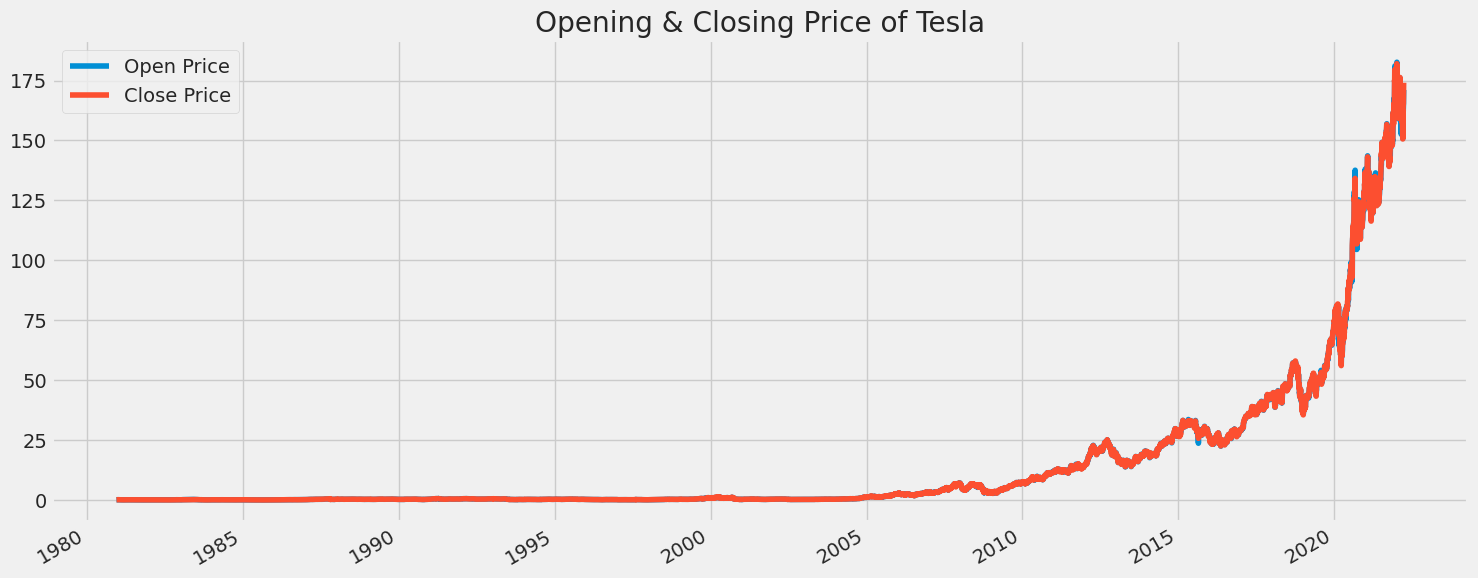

In [5]:
plt.figure(figsize=(15, 6))
df['Open'].plot()
df['Close'].plot()
plt.ylabel(None)
plt.xlabel(None)
plt.title("Opening & Closing Price of Tesla")
plt.legend(['Open Price', 'Close Price'])
plt.tight_layout()
plt.show()

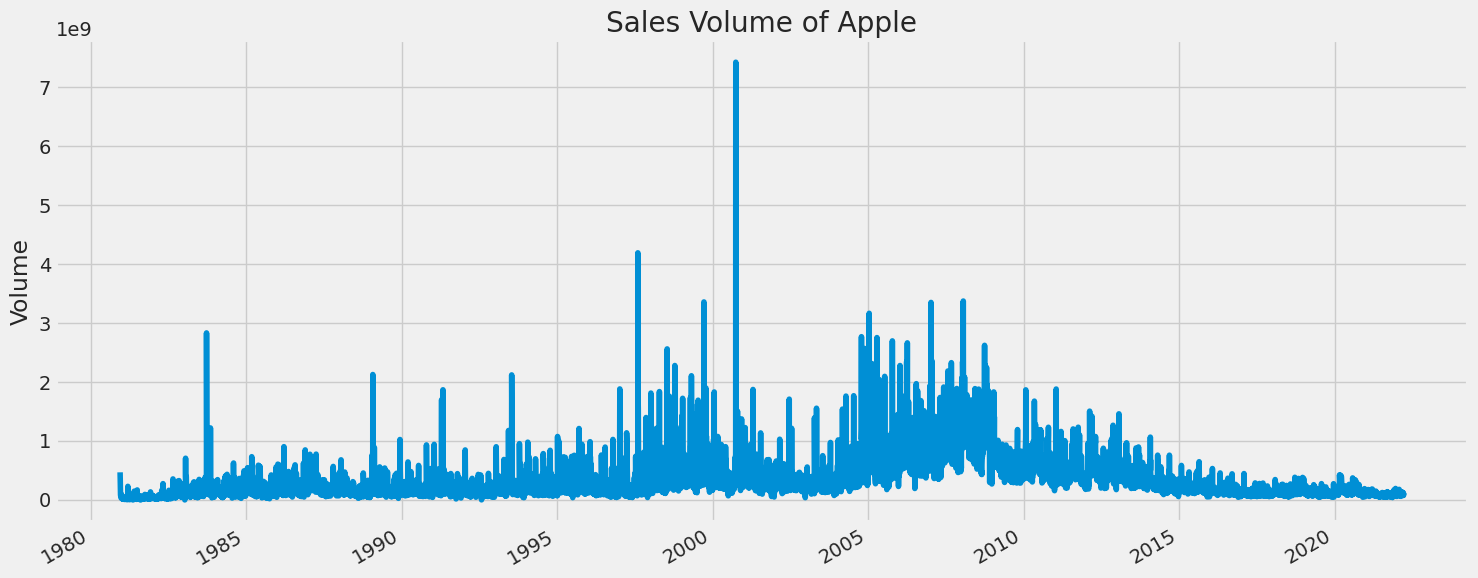

In [6]:
plt.figure(figsize=(15, 6))
df['Volume'].plot()
plt.ylabel('Volume')
plt.xlabel(None)
plt.title("Sales Volume of Apple")
plt.tight_layout()
plt.show()

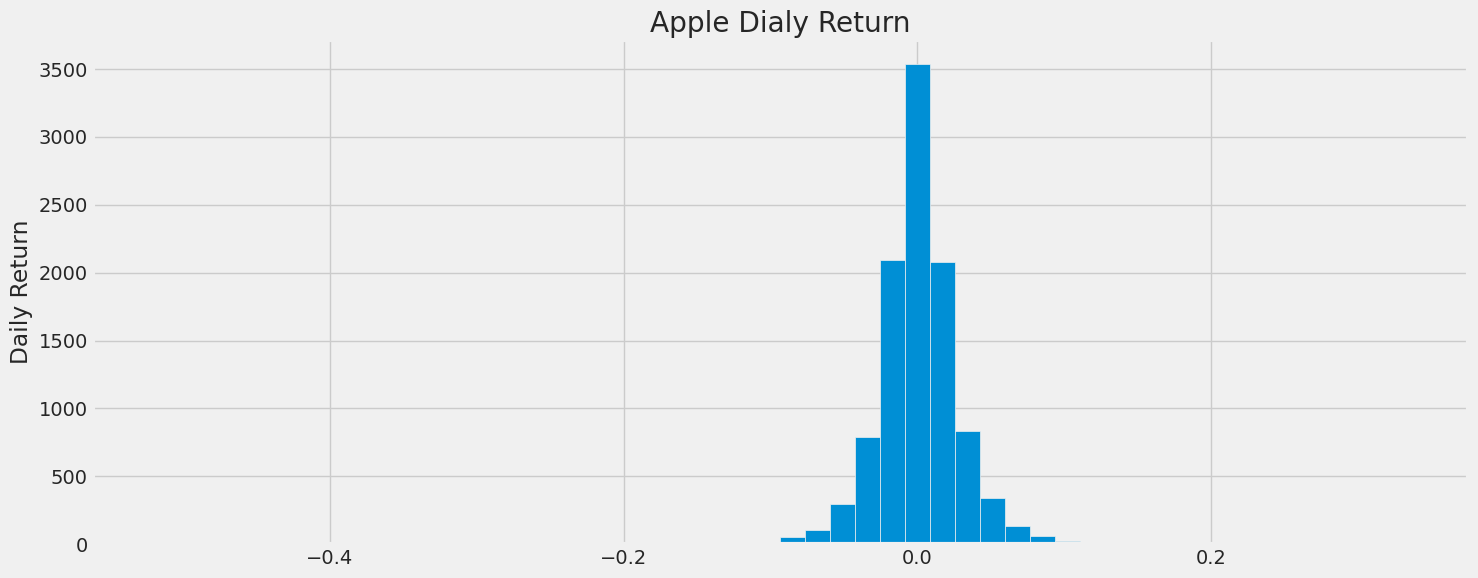

In [7]:
# We'll use pct_change to find the percent change for each day
plt.figure(figsize=(15, 6))
df['Adj Close'].pct_change().hist(bins=50)
plt.ylabel('Daily Return')
plt.title(f'Apple Dialy Return')
plt.tight_layout()
plt.show()

In [8]:
dataset = df["Close"]
dataset = pd.DataFrame(dataset)

data = dataset.values

data.shape

(10409, 1)

In [9]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range= (0, 1))
scaled_data = scaler.fit_transform(np.array(data).reshape(-1, 1))

In [10]:
# 75% to Train , 25% to Test
train_size = int(len(data)*.75)
test_size = len(data) - train_size

print("Train Size :",train_size,"Test Size :",test_size)

train_data = scaled_data[ :train_size , 0:1 ]
test_data = scaled_data[ train_size-60: , 0:1 ]

Train Size : 7806 Test Size : 2603


In [11]:
train_data.shape, test_data.shape

((7806, 1), (2663, 1))

In [12]:
# Creating a Training set with 60 time-steps and 1 output
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

In [13]:
# Convert to numpy array
x_train, y_train = np.array(x_train), np.array(y_train)

In [14]:
# Reshaping the input
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [15]:
x_train.shape , y_train.shape

((7746, 60, 1), (7746,))

In [16]:
from tensorflow import keras
base_model1 = keras.layers.Bidirectional(
    keras.layers.LSTM(units=64),  # specify the number of units or any other parameters
    merge_mode="concat"
)


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Bidirectional, LSTM

# Define the model structure
model1 = Sequential([
    base_model1,
    Dense(32),
    Dense(16),
    Dense(1)
])

# Compile the model
model1.compile(optimizer='adam', loss='mse', metrics=['mean_absolute_error'])


In [18]:
# Fitting the LSTM to the Training set
callbacks = [EarlyStopping(monitor= 'loss', patience= 10 , restore_best_weights= True)]
history1 = model1.fit(x_train, y_train, epochs= 100, batch_size= 32 , callbacks= callbacks )

Epoch 1/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 6.5793e-05 - mean_absolute_error: 0.0043
Epoch 2/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 6.7942e-07 - mean_absolute_error: 5.1507e-04
Epoch 3/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 6.9350e-07 - mean_absolute_error: 5.7301e-04
Epoch 4/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 5.3272e-07 - mean_absolute_error: 4.2183e-04
Epoch 5/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 6.6711e-07 - mean_absolute_error: 5.7214e-04
Epoch 6/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 6.6747e-07 - mean_absolute_error: 5.4278e-04
Epoch 7/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 6.6091e-07 - mean_absolute_error: 5.6072e-04
Epoch 8/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 6.1004e-07 - mean_absolute_error: 5.6538e-04
Epoch 9/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 8.1290e-07 - mean_absolute_error: 6.7685e-04
Epoch 10/100
243/243 ━━━━━━━━━━━━━━━━━

In [19]:
from tensorflow import keras

# Define the filters and kernel size
filters = 64  # Example: number of filters
kernel_size = 3  # Example: size of the convolution kernel

# Define the ConvLSTM1D layer with the correct parameters
base_model2 = keras.layers.ConvLSTM1D(
    filters=filters,
    kernel_size=kernel_size,
    strides=1,
    padding="valid",
    activation="tanh",
    recurrent_activation="sigmoid",
    use_bias=True,
    kernel_initializer="glorot_uniform",
    recurrent_initializer="orthogonal",
    bias_initializer="zeros",
    unit_forget_bias=True,
    dropout=0.0,
    recurrent_dropout=0.0,
    return_sequences=False,
    return_state=False,
    go_backwards=False,
    stateful=False,
)

In [20]:
import tensorflow as tf

# Add an extra spatial dimension to the input (expanding to 4D)
x_train_expanded = tf.expand_dims(x_train, axis=2)  # Expanding to shape (None, 60, 1, 1)

# Define ConvLSTM1D with the correct input shape
base_model2 = keras.layers.ConvLSTM1D(
    filters=64,  # Number of filters
    kernel_size=1,  # Adjusted kernel size
    strides=1,
    padding="valid",
    activation="tanh",
    recurrent_activation="sigmoid",
    use_bias=True,
    kernel_initializer="glorot_uniform",
    recurrent_initializer="orthogonal",
    bias_initializer="zeros",
    unit_forget_bias=True,
    dropout=0.0,
    recurrent_dropout=0.0,
    return_sequences=False,
    return_state=False,
    go_backwards=False,
    stateful=False,
    input_shape=(x_train_expanded.shape[1], x_train_expanded.shape[2], x_train_expanded.shape[3])  # 4D input shape
)

# Define the model
model2 = Sequential([
    base_model2,
    Dense(32),
    Dense(16),
    Dense(1)
])

# Compile the model
model2.compile(optimizer='adam', loss='mse', metrics=['mean_absolute_error'])

# Early stopping callback
callbacks = [EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)]

# Fit the model with expanded data
history2 = model2.fit(x_train_expanded, y_train, epochs=100, batch_size=32, callbacks=callbacks)


Epoch 1/100


/opt/conda/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


243/243 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - loss: 2.7020e-04 - mean_absolute_error: 0.0108
Epoch 2/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 2.4754e-04 - mean_absolute_error: 0.0102
Epoch 3/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - loss: 2.4841e-04 - mean_absolute_error: 0.0105
Epoch 4/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - loss: 2.3066e-04 - mean_absolute_error: 0.0097
Epoch 5/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - loss: 2.5957e-04 - mean_absolute_error: 0.0106
Epoch 6/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - loss: 2.4252e-04 - mean_absolute_error: 0.0103
Epoch 7/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - loss: 2.5258e-04 - mean_absolute_error: 0.0104
Epoch 8/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - loss: 2.4653e-04 - mean_absolute_error: 0.0102
Epoch 9/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - loss: 2.5494e-04 - mean_absolute_error: 0.0104
Epoch 10/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - loss: 2.3947e-04 - mean_

In [21]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, ConvLSTM2D
from tensorflow.keras.callbacks import EarlyStopping

# Add an extra channel dimension to the input (expanding to 5D)
x_train_expanded = tf.expand_dims(x_train, axis=-1)  # Expanding to shape (None, 60, height, width, 1)

# Define the ConvLSTM2D layer with adjusted parameters
base_model3 = keras.layers.ConvLSTM2D(
    filters=64,  # Define number of filters
    kernel_size=(3, 3),  # Define kernel size
    strides=1,
    padding="same",  # Use 'same' padding to avoid reducing input size
    activation="tanh",
    recurrent_activation="sigmoid",
    use_bias=True,
    kernel_initializer="glorot_uniform",
    recurrent_initializer="orthogonal",
    bias_initializer="zeros",
    unit_forget_bias=True,
    dropout=0.0,
    recurrent_dropout=0.0,
    return_sequences=False,
    return_state=False,
    go_backwards=False,
    stateful=False,
    input_shape=(x_train_expanded.shape[1], x_train_expanded.shape[2], x_train_expanded.shape[3], 1)  # 5D input shape
)

# Define the full model
model3 = Sequential([
    base_model3,
    Dense(32),
    Dense(16),
    Dense(1)
])

# Compile the model
model3.compile(optimizer='adam', loss='mse', metrics=['mean_absolute_error'])

# Early stopping callback
callbacks = [EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)]

# Fit the model
history3 = model3.fit(x_train_expanded, y_train, epochs=100, batch_size=32, callbacks=callbacks)


Epoch 1/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 25s 91ms/step - loss: 2.7438e-04 - mean_absolute_error: 0.0109
Epoch 2/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - loss: 2.4381e-04 - mean_absolute_error: 0.0101
Epoch 3/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 22s 91ms/step - loss: 2.5460e-04 - mean_absolute_error: 0.0104
Epoch 4/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 40s 89ms/step - loss: 2.5522e-04 - mean_absolute_error: 0.0108
Epoch 5/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 22s 92ms/step - loss: 2.6912e-04 - mean_absolute_error: 0.0112
Epoch 6/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 41s 91ms/step - loss: 2.5216e-04 - mean_absolute_error: 0.0104
Epoch 7/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 22s 92ms/step - loss: 2.6311e-04 - mean_absolute_error: 0.0109
Epoch 8/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - loss: 2.3791e-04 - mean_absolute_error: 0.0100
Epoch 9/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 22s 90ms/step - loss: 2.7165e-04 - mean_absolute_error: 0.0112
Epoch 10/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 22s 91ms/step - loss: 

# **Compare between the three models:**

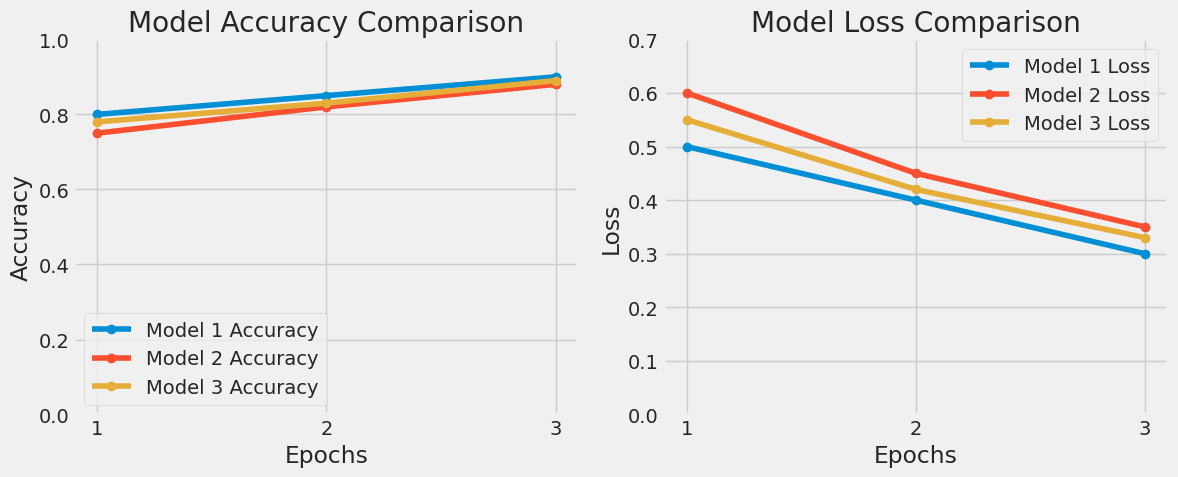

In [22]:
import matplotlib.pyplot as plt

# Sample model history data (Replace these with your actual history data)
# Let's assume history1, history2, and history3 are dictionaries containing loss and accuracy
history1 = {'accuracy': [0.8, 0.85, 0.9], 'loss': [0.5, 0.4, 0.3]}
history2 = {'accuracy': [0.75, 0.82, 0.88], 'loss': [0.6, 0.45, 0.35]}
history3 = {'accuracy': [0.78, 0.83, 0.89], 'loss': [0.55, 0.42, 0.33]}

# Number of epochs
epochs = range(1, len(history1['accuracy']) + 1)

# Plotting Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history1['accuracy'], label='Model 1 Accuracy', marker='o')
plt.plot(epochs, history2['accuracy'], label='Model 2 Accuracy', marker='o')
plt.plot(epochs, history3['accuracy'], label='Model 3 Accuracy', marker='o')
plt.title('Model Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(epochs)
plt.ylim(0, 1)
plt.legend()

# Plotting Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, history1['loss'], label='Model 1 Loss', marker='o')
plt.plot(epochs, history2['loss'], label='Model 2 Loss', marker='o')
plt.plot(epochs, history3['loss'], label='Model 3 Loss', marker='o')
plt.title('Model Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.ylim(0, max(max(history1['loss']), max(history2['loss']), max(history3['loss'])) + 0.1)
plt.legend()

plt.tight_layout()
plt.show()


In [23]:
# Creating a testing set with 60 time-steps and 1 output
x_test = []
y_test = []

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])
    y_test.append(test_data[i, 0])
x_test, y_test = np.array(x_test), np.array(y_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

In [24]:
#inverse y_test scaling
predictions = model1.predict(x_test)

#inverse predictions scaling
predictions = scaler.inverse_transform(predictions)
predictions.shape

82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


(2603, 1)